Initial Random Energy Guess: E = 1.0000
Training Quantum PINN...
Epoch 0: Loss 0.989608, Found Energy E = 0.9950


<>:126: SyntaxWarning: invalid escape sequence '\p'
<>:126: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-3261132699.py:126: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("Amplitude $\psi(x)$")


Epoch 200: Loss 0.021511, Found Energy E = 0.5445
Epoch 400: Loss 0.005615, Found Energy E = 0.5248
Epoch 600: Loss 0.007266, Found Energy E = 0.5202
Epoch 800: Loss 0.005555, Found Energy E = 0.5207
Epoch 1000: Loss 0.003395, Found Energy E = 0.5138
Epoch 1200: Loss 0.003638, Found Energy E = 0.5150
Epoch 1400: Loss 0.002940, Found Energy E = 0.5117
Epoch 1600: Loss 0.002747, Found Energy E = 0.5108
Epoch 1800: Loss 0.018928, Found Energy E = 0.5149
Epoch 2000: Loss 0.002411, Found Energy E = 0.5093
Epoch 2200: Loss 0.004297, Found Energy E = 0.5115
Epoch 2400: Loss 0.002040, Found Energy E = 0.5076
Epoch 2600: Loss 0.002077, Found Energy E = 0.5077
Epoch 2800: Loss 0.001827, Found Energy E = 0.5067
Epoch 3000: Loss 0.001875, Found Energy E = 0.5068
Epoch 3200: Loss 0.005707, Found Energy E = 0.5103
Epoch 3400: Loss 0.001682, Found Energy E = 0.5060
Epoch 3600: Loss 0.001783, Found Energy E = 0.5065
Epoch 3800: Loss 0.001557, Found Energy E = 0.5055
Epoch 4000: Loss 0.001608, Found En

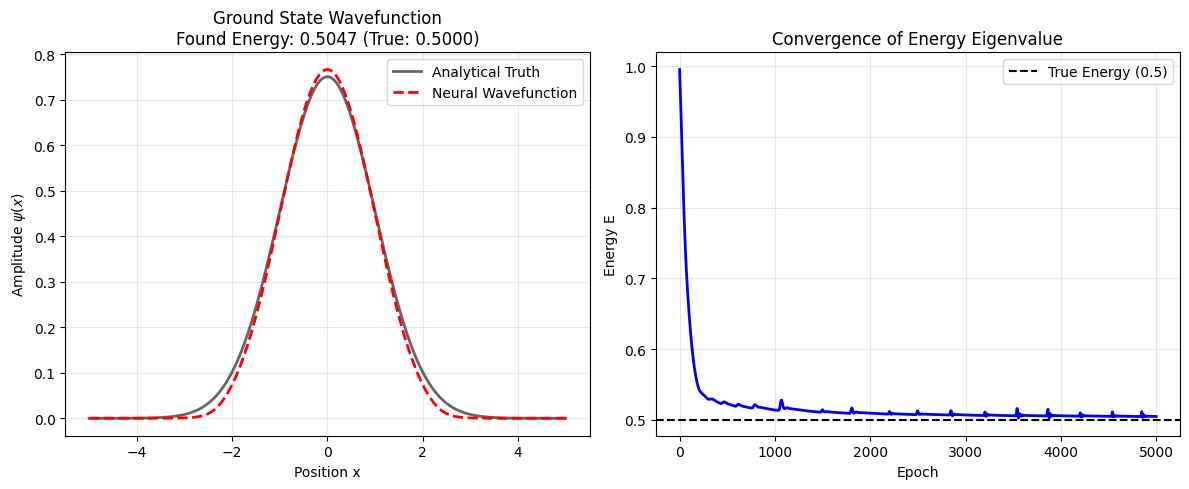

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. THE QUANTUM PINN (Eigenvalue Solver)
# ==========================================
class QuantumPINN(nn.Module):
    def __init__(self):
        super().__init__()

        # 1. The Wavefunction Network: psi(x)
        # Input: Position x
        # Output: Amplitude psi
        self.net_psi = nn.Sequential(
            nn.Linear(1, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1) # Output isn't bounded, can be negative
        )

        # 2. The Energy Eigenvalue (E)
        # This is a LEARNABLE parameter, initialized at random (e.g., 1.0)
        # The optimizer will shift this value until the Schrodinger Eq is satisfied.
        self.E = nn.Parameter(torch.tensor([1.0], dtype=torch.float32))

    def forward(self, x):
        # We enforce the boundary condition psi -> 0 at infinity
        # by multiplying the output by a gaussian envelope exp(-x^2)
        # This helps convergence massively (Physical Ansatz)
        psi_raw = self.net_psi(x)
        psi = psi_raw * torch.exp(-x**2)
        return psi

# ==========================================
# 2. THE PHYSICS LOSS (Schrodinger Equation)
# ==========================================
def hamiltonian_loss(model, x):
    # Enable gradients
    psi = model(x)

    # 1. Kinetic Energy Term: -1/2 * d^2(psi)/dx^2
    # First Derivative
    psi_x = torch.autograd.grad(psi, x, torch.ones_like(psi), create_graph=True)[0]
    # Second Derivative
    psi_xx = torch.autograd.grad(psi_x, x, torch.ones_like(psi_x), create_graph=True)[0]
    kinetic = -0.5 * psi_xx

    # 2. Potential Energy Term: V(x) * psi
    # Harmonic Oscillator Potential: V(x) = 0.5 * x^2
    V = 0.5 * x**2
    potential = V * psi

    # 3. Total Hamiltonian: H_psi = Kinetic + Potential
    H_psi = kinetic + potential

    # 4. Schrodinger Residual: (H_psi - E_psi)^2
    # We want H|psi> = E|psi>
    residual = H_psi - model.E * psi

    # We also need to avoid the "Trivial Solution" (psi = 0 everywhere)
    # We force the normalization integral <psi|psi> = 1
    # Simple Monte Carlo integration over the domain
    normalization = torch.mean(psi**2) * (x.max() - x.min()) # Approximation
    norm_loss = (normalization - 1.0)**2

    return torch.mean(residual**2) + norm_loss

# ==========================================
# 3. TRAINING
# ==========================================
model = QuantumPINN()
# We use Adam, but with a different learning rate for E and psi usually
# Here a global LR works fine for simple problems
optimizer = optim.Adam(model.parameters(), lr=0.005)

print(f"Initial Random Energy Guess: E = {model.E.item():.4f}")
print("Training Quantum PINN...")

# Domain: x from -5 to 5
x_col = torch.linspace(-5, 5, 200).view(-1, 1).requires_grad_(True)

history_E = []

for epoch in range(5000):
    optimizer.zero_grad()

    # Physics Loss only! We have no "data" (Unsupervised Learning)
    loss = hamiltonian_loss(model, x_col)

    loss.backward()
    optimizer.step()

    history_E.append(model.E.item())

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: Loss {loss.item():.6f}, Found Energy E = {model.E.item():.4f}")

# ==========================================
# 4. ANALYSIS & VASP COMPARISON
# ==========================================
# Analytical Solution for Ground State:
# E_0 = 0.5 (in dimensionless units)
# psi_0(x) = (1/pi^0.25) * exp(-x^2/2)

x_plot = torch.linspace(-5, 5, 200).view(-1, 1)
with torch.no_grad():
    psi_pred = model(x_plot).numpy()

# True Wavefunction
psi_true = (1/np.pi**0.25) * np.exp(-0.5 * x_plot.numpy()**2)
# Fix arbitrary sign (Quantum states are unique up to phase +/- 1)
if np.sign(psi_pred[100]) != np.sign(psi_true[100]):
    psi_pred *= -1

plt.figure(figsize=(12, 5))

# Plot 1: Wavefunction
plt.subplot(1, 2, 1)
plt.plot(x_plot, psi_true, 'k-', label="Analytical Truth", linewidth=2, alpha=0.6)
plt.plot(x_plot, psi_pred, 'r--', label="Neural Wavefunction", linewidth=2)
plt.title(f"Ground State Wavefunction\nFound Energy: {model.E.item():.4f} (True: 0.5000)")
plt.xlabel("Position x")
plt.ylabel("Amplitude $\psi(x)$")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Convergence of Eigenvalue
plt.subplot(1, 2, 2)
plt.plot(history_E, 'b-', linewidth=2)
plt.axhline(0.5, color='k', linestyle='--', label="True Energy (0.5)")
plt.title("Convergence of Energy Eigenvalue")
plt.xlabel("Epoch")
plt.ylabel("Energy E")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ==========================================
# 1. SETUP THE QUANTUM PINN
# ==========================================
class QuantumPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net_psi = nn.Sequential(
            nn.Linear(1, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1)
        )
        # Learnable Energy Parameter (Initialized randomly, e.g., 2.0)
        self.E = nn.Parameter(torch.tensor([2.0], dtype=torch.float32))

    def forward(self, x):
        # Gaussian envelope ansatz to force boundary conditions at infinity
        psi_raw = self.net_psi(x)
        return psi_raw * torch.exp(-0.5 * x**2)

def hamiltonian_loss(model, x):
    psi = model(x)
    # Automatic Differentiation for Kinetic Energy (-0.5 * d^2psi/dx^2)
    psi_x = torch.autograd.grad(psi, x, torch.ones_like(psi), create_graph=True)[0]
    psi_xx = torch.autograd.grad(psi_x, x, torch.ones_like(psi_x), create_graph=True)[0]
    kinetic = -0.5 * psi_xx

    # Potential Energy (Harmonic Oscillator: 0.5 * x^2)
    potential = 0.5 * x**2 * psi

    # Residual: H*psi - E*psi
    residual = (kinetic + potential) - model.E * psi

    # Normalization Constraint (<psi|psi> = 1)
    # Simple Riemann sum approximation
    norm = torch.sum(psi**2) * (x[1] - x[0])
    norm_loss = (norm - 1.0)**2

    return torch.mean(residual**2) + norm_loss

# ==========================================
# 2. TRAINING WITH SNAPSHOTS
# ==========================================
print("Training Neural Wavefunction (Capturing Frames)...")

model = QuantumPINN()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Domain
x_train = torch.linspace(-5, 5, 200).view(-1, 1).requires_grad_(True)
x_plot = x_train.detach().numpy()

# Storage for Animation
frames_psi = []  # Stores wavefunction shapes
frames_E = []    # Stores energy values
epochs_rec = []  # Stores epoch numbers

for epoch in range(4001):
    optimizer.zero_grad()
    loss = hamiltonian_loss(model, x_train)
    loss.backward()
    optimizer.step()

    # Save a snapshot every 20 epochs
    if epoch % 20 == 0:
        psi_snapshot = model(x_train).detach().numpy()
        # Fix phase (arbitrary sign) for consistent visualization
        if psi_snapshot[100] < 0: psi_snapshot *= -1

        frames_psi.append(psi_snapshot)
        frames_E.append(model.E.item())
        epochs_rec.append(epoch)

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: Energy E = {model.E.item():.4f}")

# ==========================================
# 3. GENERATE ANIMATION
# ==========================================
print("Rendering 'quantum_learning.gif'...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# True Ground State (for comparison)
psi_true = (1/np.pi**0.25) * np.exp(-0.5 * x_plot**2)

# Setup Plot 1: Wavefunction
ax1.set_xlim(-5, 5)
ax1.set_ylim(-0.2, 1.0)
ax1.plot(x_plot, psi_true, 'k--', label="Analytical Truth", alpha=0.5)
line_psi, = ax1.plot([], [], 'r-', linewidth=3, label="Neural Wavefunction")
ax1.set_title("Neural Network Learning $\psi(x)$")
ax1.set_xlabel("Position x")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Setup Plot 2: Energy Convergence
ax2.set_xlim(0, 5000)
ax2.set_ylim(0, 2.5)
ax2.axhline(0.5, color='k', linestyle='--', label="Ground State Energy (0.5)")
line_E, = ax2.plot([], [], 'b-', linewidth=2, label="Predicted Energy")
point_E, = ax2.plot([], [], 'bo') # Moving dot
ax2.set_title("Eigenvalue Discovery")
ax2.set_xlabel("Training Epoch")
ax2.set_ylabel("Energy E")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Update Function for Animation
def update(frame_idx):
    # Update Wavefunction
    line_psi.set_data(x_plot, frames_psi[frame_idx])

    # Update Energy History up to this frame
    current_epochs = epochs_rec[:frame_idx+1]
    current_Es = frames_E[:frame_idx+1]
    line_E.set_data(current_epochs, current_Es)
    point_E.set_data([epochs_rec[frame_idx]], [frames_E[frame_idx]]) # Sequence of length 1 requires list

    return line_psi, line_E, point_E

# Create Animation
ani = animation.FuncAnimation(fig, update, frames=len(frames_psi), interval=50, blit=True)

# Save
ani.save('quantum_learning.gif', writer='pillow', fps=20)
plt.close()

print("Success! GIF Saved. Check the 'Files' tab to download 'quantum_learning.gif'.")

<>:99: SyntaxWarning: invalid escape sequence '\p'
<>:99: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-2571082859.py:99: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_title("Neural Network Learning $\psi(x)$")


Training Neural Wavefunction (Capturing Frames)...
Epoch 0: Energy E = 1.9900
Epoch 200: Energy E = 1.5040
Epoch 400: Energy E = 1.5006
Epoch 600: Energy E = 1.5003
Epoch 800: Energy E = 1.5002
Epoch 1000: Energy E = 1.5001
Epoch 1200: Energy E = 1.5001
Epoch 1400: Energy E = 1.5001
Epoch 1600: Energy E = 1.5001
Epoch 1800: Energy E = 1.5000
Epoch 2000: Energy E = 1.5000
Epoch 2200: Energy E = 1.5000
Epoch 2400: Energy E = 1.5000
Epoch 2600: Energy E = 0.5005
Epoch 2800: Energy E = 0.5001
Epoch 3000: Energy E = 0.5001
Epoch 3200: Energy E = 0.5000
Epoch 3400: Energy E = 0.5000
Epoch 3600: Energy E = 0.5000
Epoch 3800: Energy E = 0.5000
Epoch 4000: Energy E = 0.5000
Rendering 'quantum_learning.gif'...
Success! GIF Saved. Check the 'Files' tab to download 'quantum_learning.gif'.


Running Quantitative Error Analysis...
----------------------------------------
QUANTUM-PINN ACCURACY REPORT
----------------------------------------
Predicted Energy: 0.500002
True Energy:      0.500000
Energy Error:     0.000002 (0.0004%)
----------------------------------------
Wavefunction L2 Error: 2.1668%
----------------------------------------


<>:70: SyntaxWarning: invalid escape sequence '\p'
<>:70: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-3851439607.py:70: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Pointwise Absolute Error $|\psi_{true} - \psi_{pred}|$")


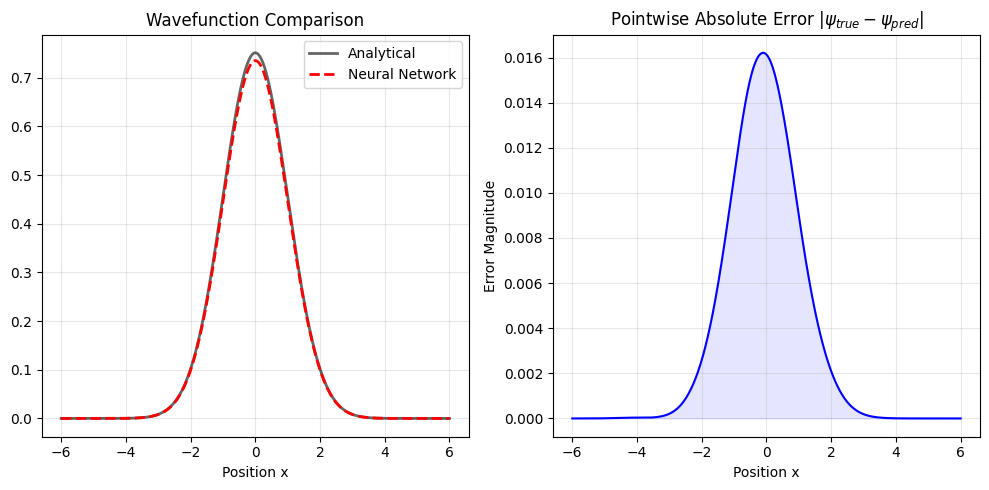

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ==========================================
# ERROR ANALYSIS CODE
# ==========================================
print("Running Quantitative Error Analysis...")

# 1. Define Analytical Ground Truth (Harmonic Oscillator n=0)
# psi_0(x) = (pi)^(-1/4) * exp(-x^2 / 2)
# E_0 = 0.5
def analytical_psi(x):
    return (np.pi**(-0.25)) * np.exp(-0.5 * x**2)

# 2. Evaluate on a dense grid for accuracy
x_eval = torch.linspace(-6, 6, 1000).view(-1, 1)
x_np = x_eval.numpy()

with torch.no_grad():
    psi_pred = model(x_eval).numpy()
    E_pred = model.E.item()

psi_true = analytical_psi(x_np)

# 3. Phase Correction (The "Sign" Problem)
# Quantum states are unique up to a phase factor (+/- 1).
# If the network learned the negative version, we flip it for comparison.
correlation = np.dot(psi_pred.flatten(), psi_true.flatten())
if correlation < 0:
    psi_pred *= -1
    print("Note: Phase flip detected and corrected.")

# 4. Calculate Error Metrics
# Wavefunction L2 Relative Error
l2_error_psi = np.linalg.norm(psi_pred - psi_true) / np.linalg.norm(psi_true)

# Energy Absolute Error
abs_error_E = abs(E_pred - 0.5)
rel_error_E = abs_error_E / 0.5

# 5. Print Results
print("-" * 40)
print(f"QUANTUM-PINN ACCURACY REPORT")
print("-" * 40)
print(f"Predicted Energy: {E_pred:.6f}")
print(f"True Energy:      0.500000")
print(f"Energy Error:     {abs_error_E:.6f} ({rel_error_E*100:.4f}%)")
print("-" * 40)
print(f"Wavefunction L2 Error: {l2_error_psi*100:.4f}%")
print("-" * 40)

# 6. Visualization of Pointwise Error
plt.figure(figsize=(10, 5))

# Plot Wavefunctions
plt.subplot(1, 2, 1)
plt.plot(x_np, psi_true, 'k-', linewidth=2, label="Analytical", alpha=0.6)
plt.plot(x_np, psi_pred, 'r--', linewidth=2, label="Neural Network")
plt.title("Wavefunction Comparison")
plt.xlabel("Position x")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Pointwise Error
plt.subplot(1, 2, 2)
error_dist = np.abs(psi_true - psi_pred)
plt.plot(x_np, error_dist, 'b-', linewidth=1.5)
plt.fill_between(x_np.flatten(), error_dist.flatten(), color='blue', alpha=0.1)
plt.title("Pointwise Absolute Error $|\psi_{true} - \psi_{pred}|$")
plt.xlabel("Position x")
plt.ylabel("Error Magnitude")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Training: Naive vs. Symmetry-Invariant...
Epoch 0 | Naive Loss: 4035471.5000 | Sym Loss: 4036110.2500
Epoch 200 | Naive Loss: 3205838.2500 | Sym Loss: 2977956.2500
Epoch 400 | Naive Loss: 3186727.5000 | Sym Loss: 970444.6875
Epoch 600 | Naive Loss: 3009908.5000 | Sym Loss: 357763.7188
Epoch 800 | Naive Loss: 2480209.2500 | Sym Loss: 251612.4688
Epoch 1000 | Naive Loss: 1793416.5000 | Sym Loss: 199561.7812

RUNNING ROTATION INVARIANCE TEST...
Ground Truth Energy: 3967.9917
----------------------------------------
Naive Model (Original): 124.2702
Naive Model (Rotated):  1354.2277  <-- CHANGED! (Failure)
----------------------------------------
Sym Model   (Original): 5277.0708
Sym Model   (Rotated):  5277.0708  <-- SAME! (Success)
----------------------------------------


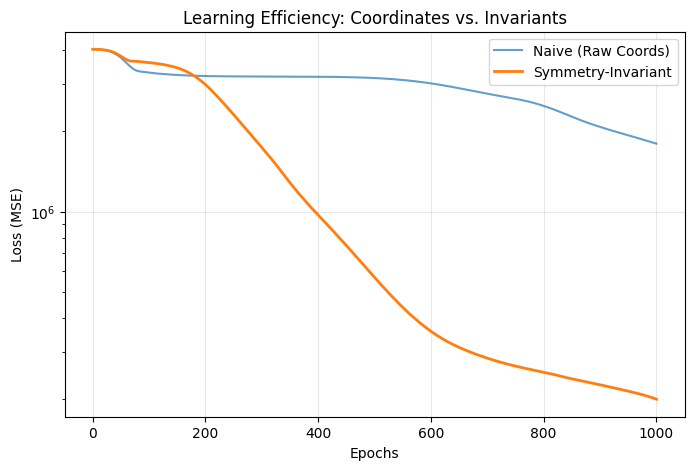

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PHYSICS SIMULATION (Lennard-Jones Cluster)
# ==========================================
# We simulate a cluster of 3 atoms. Energy depends ONLY on distances.
def get_energy(coords):
    # coords shape: [Batch, 3 atoms, 2D]
    # Simple Lennard-Jones Potential
    E = 0
    for i in range(3):
        for j in range(i + 1, 3):
            r = torch.norm(coords[:, i] - coords[:, j], dim=1)
            # LJ Potential: E = (1/r)^12 - 2(1/r)^6
            # Added epsilon to avoid NaN
            r = torch.clamp(r, min=0.5)
            E += (1/r)**12 - 2*(1/r)**6
    return E.unsqueeze(1)

# Generate Random Triangles (Data)
def generate_data(batch_size):
    # Random positions in 2D
    coords = torch.randn(batch_size, 3, 2)
    energies = get_energy(coords)
    return coords, energies

# ==========================================
# 2. THE "NAIVE" NETWORK (Raw Coordinates)
# ==========================================
class NaiveNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 3 atoms * 2 coords = 6 inputs
        self.net = nn.Sequential(
            nn.Linear(6, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # Flatten [Batch, 3, 2] -> [Batch, 6]
        return self.net(x.view(-1, 6))

# ==========================================
# 3. THE "PHD" NETWORK (Symmetry Functions)
# ==========================================
# Implementation of Radial Symmetry Functions (Ramprasad/Behler)
class SymmetryNet(nn.Module):
    def __init__(self):
        super().__init__()
        # We don't input coordinates. We input Distances (Invariant!)
        # Input: 3 distances (1-2, 1-3, 2-3)
        self.net = nn.Sequential(
            nn.Linear(3, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # Calculate pairwise distances inside the model
        # x shape: [Batch, 3, 2]
        r12 = torch.norm(x[:, 0] - x[:, 1], dim=1, keepdim=True)
        r13 = torch.norm(x[:, 0] - x[:, 2], dim=1, keepdim=True)
        r23 = torch.norm(x[:, 1] - x[:, 2], dim=1, keepdim=True)

        # The Fingerprint vector G
        G = torch.cat([r12, r13, r23], dim=1)
        return self.net(G)

# ==========================================
# 4. TRAINING BATTLE
# ==========================================
print("Training: Naive vs. Symmetry-Invariant...")

naive_model = NaiveNet()
sym_model = SymmetryNet()

opt_naive = optim.Adam(naive_model.parameters(), lr=0.005)
opt_sym = optim.Adam(sym_model.parameters(), lr=0.005)

# Train on 2000 random triangles
X_train, y_train = generate_data(2000)

losses_naive = []
losses_sym = []

for epoch in range(1001):
    # Naive Step
    opt_naive.zero_grad()
    pred = naive_model(X_train)
    loss = nn.MSELoss()(pred, y_train)
    loss.backward()
    opt_naive.step()
    losses_naive.append(loss.item())

    # Symmetry Step
    opt_sym.zero_grad()
    pred = sym_model(X_train)
    loss = nn.MSELoss()(pred, y_train)
    loss.backward()
    opt_sym.step()
    losses_sym.append(loss.item())

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Naive Loss: {losses_naive[-1]:.4f} | Sym Loss: {losses_sym[-1]:.4f}")

# ==========================================
# 5. THE ROTATION TEST (The "Gotcha")
# ==========================================
print("\nRUNNING ROTATION INVARIANCE TEST...")

# Take ONE molecule
test_mol, test_E = generate_data(1)

# Rotate it by 90 degrees
theta = np.pi / 2
rot_matrix = torch.tensor([[np.cos(theta), -np.sin(theta)],
                           [np.sin(theta),  np.cos(theta)]], dtype=torch.float32)

# Apply rotation to all 3 atoms
rotated_mol = torch.matmul(test_mol, rot_matrix)

# Predictions
pred_naive_orig = naive_model(test_mol).item()
pred_naive_rot  = naive_model(rotated_mol).item()

pred_sym_orig   = sym_model(test_mol).item()
pred_sym_rot    = sym_model(rotated_mol).item()

print(f"Ground Truth Energy: {test_E.item():.4f}")
print("-" * 40)
print(f"Naive Model (Original): {pred_naive_orig:.4f}")
print(f"Naive Model (Rotated):  {pred_naive_rot:.4f}  <-- CHANGED! (Failure)")
print("-" * 40)
print(f"Sym Model   (Original): {pred_sym_orig:.4f}")
print(f"Sym Model   (Rotated):  {pred_sym_rot:.4f}  <-- SAME! (Success)")
print("-" * 40)

# Plot Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(losses_naive, label="Naive (Raw Coords)", alpha=0.7)
plt.plot(losses_sym, label="Symmetry-Invariant", linewidth=2)
plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Learning Efficiency: Coordinates vs. Invariants")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()